# Figure 3

## Timestamps

Heatmap:
Scatterplot: Last generated 3/10/2026 at 2:15pm

## Code to calculate the RBP Activity Metric and generate heatmap figure

### Load packages and read in table

In [2]:
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns
import pickle

In [3]:
# Function to get path for big table

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [4]:
# Read in data for both cell lines

data_path_HepG2 = get_path("HepG2")
data_HepG2 = pl.read_ipc(data_path_HepG2)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [5]:
data_path_K562 = get_path("K562")
data_K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


### Function to generate heatmap data

In [7]:
def plot_rbp_activity_heatmap(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    # Can test for an individual RBP
    # test = results_df[results_df["RBP"] == ""]
    # print(test)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    return heatmap_data

In [10]:
HepG2_heatmap = plot_rbp_activity_heatmap('HepG2', data_HepG2)
HepG2_heatmap.to_csv("HepG2_activity_heatmap.csv")

HepG2


In [11]:
K562_heatmap = plot_rbp_activity_heatmap('K562', data_K562)
K562_heatmap.to_csv("K562_activity_heatmap.csv")

K562


In [13]:
# Merge csvs and make into one df

# Load the two CSVs
K562 = pd.read_csv("K562_activity_heatmap.csv")
HepG2 = pd.read_csv("HepG2_activity_heatmap.csv")

# Add Cell Line column
K562["Cell Line"] = "K562"
HepG2["Cell Line"] = "HepG2"

# Merge
merged = pd.concat([K562, HepG2], ignore_index=True)

# Save
merged.to_csv("merged_heatmap.csv", index=False)

final_heatmap = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/2_figure_3/merged_activity_heatmap.csv")

### Code to plot heatmap

In [16]:
def plot_rbp_activity_heatmap_test(heatmap_data):

    plt.style.use("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/paper.mplstyle")

    # Split data
    k562_data = heatmap_data[heatmap_data["Cell Line"] == "K562"].drop(columns="Cell Line").set_index("RBP")
    hepg2_data = heatmap_data[heatmap_data["Cell Line"] == "HepG2"].drop(columns="Cell Line").set_index("RBP")

    # Get union of RBPs across both cell lines
    all_rbps = sorted(set(k562_data.index).union(set(hepg2_data.index)))
    
    # Reindex both datasets to the full RBP list
    k562_data = k562_data.reindex(all_rbps)
    hepg2_data = hepg2_data.reindex(all_rbps)

    # Ensure identical RBP order
    hepg2_data = hepg2_data.reindex(k562_data.index)

    cell_line_data = [("HepG2", hepg2_data), ("K562", k562_data)]

    top_n = len(k562_data)

    vmin = min(df.min().min() for _, df in cell_line_data)
    vmax = max(df.max().max() for _, df in cell_line_data)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.5, 0.15 * top_n),  # smaller row height
        dpi=300,
        sharex=True,
        sharey=True
    )

    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.6])

    for idx, (cell_line, heatmap) in enumerate(cell_line_data):

        sns.heatmap(
            heatmap,
            ax=axes[idx],
            cmap="seismic",
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=(idx == 0),
            cbar_ax=(cbar_ax if idx == 0 else None),
            linewidths=0.4,
            linecolor="black"
        )

        axes[idx].set_title(cell_line, fontsize=12, pad=5)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")
        axes[idx].set_facecolor("lightgray")

    # Set RBP labels
    axes[0].set_yticks(np.arange(len(all_rbps)) + 0.5)
    axes[0].set_yticklabels(all_rbps, fontsize=7, rotation=0)

    axes[1].tick_params(axis='y', left=True, labelleft=False)

    axes[0].tick_params(axis='x', labelsize=12)
    axes[1].tick_params(axis='x', labelsize=12)

    cbar_ax.set_title("Norm. Score", fontsize=12, pad=10)
    cbar_ax.tick_params(labelsize=10)

    fig.supylabel("RBP", fontsize=14, x=0.09, y=0.52, fontweight="bold")
    fig.supxlabel("Position", fontsize=14, x=0.56, y=0.00,  fontweight="bold")

    plt.subplots_adjust(left=0.22, right=0.88, top=0.95, bottom=0.08, wspace=0.05)

    plt.show()

    return axes

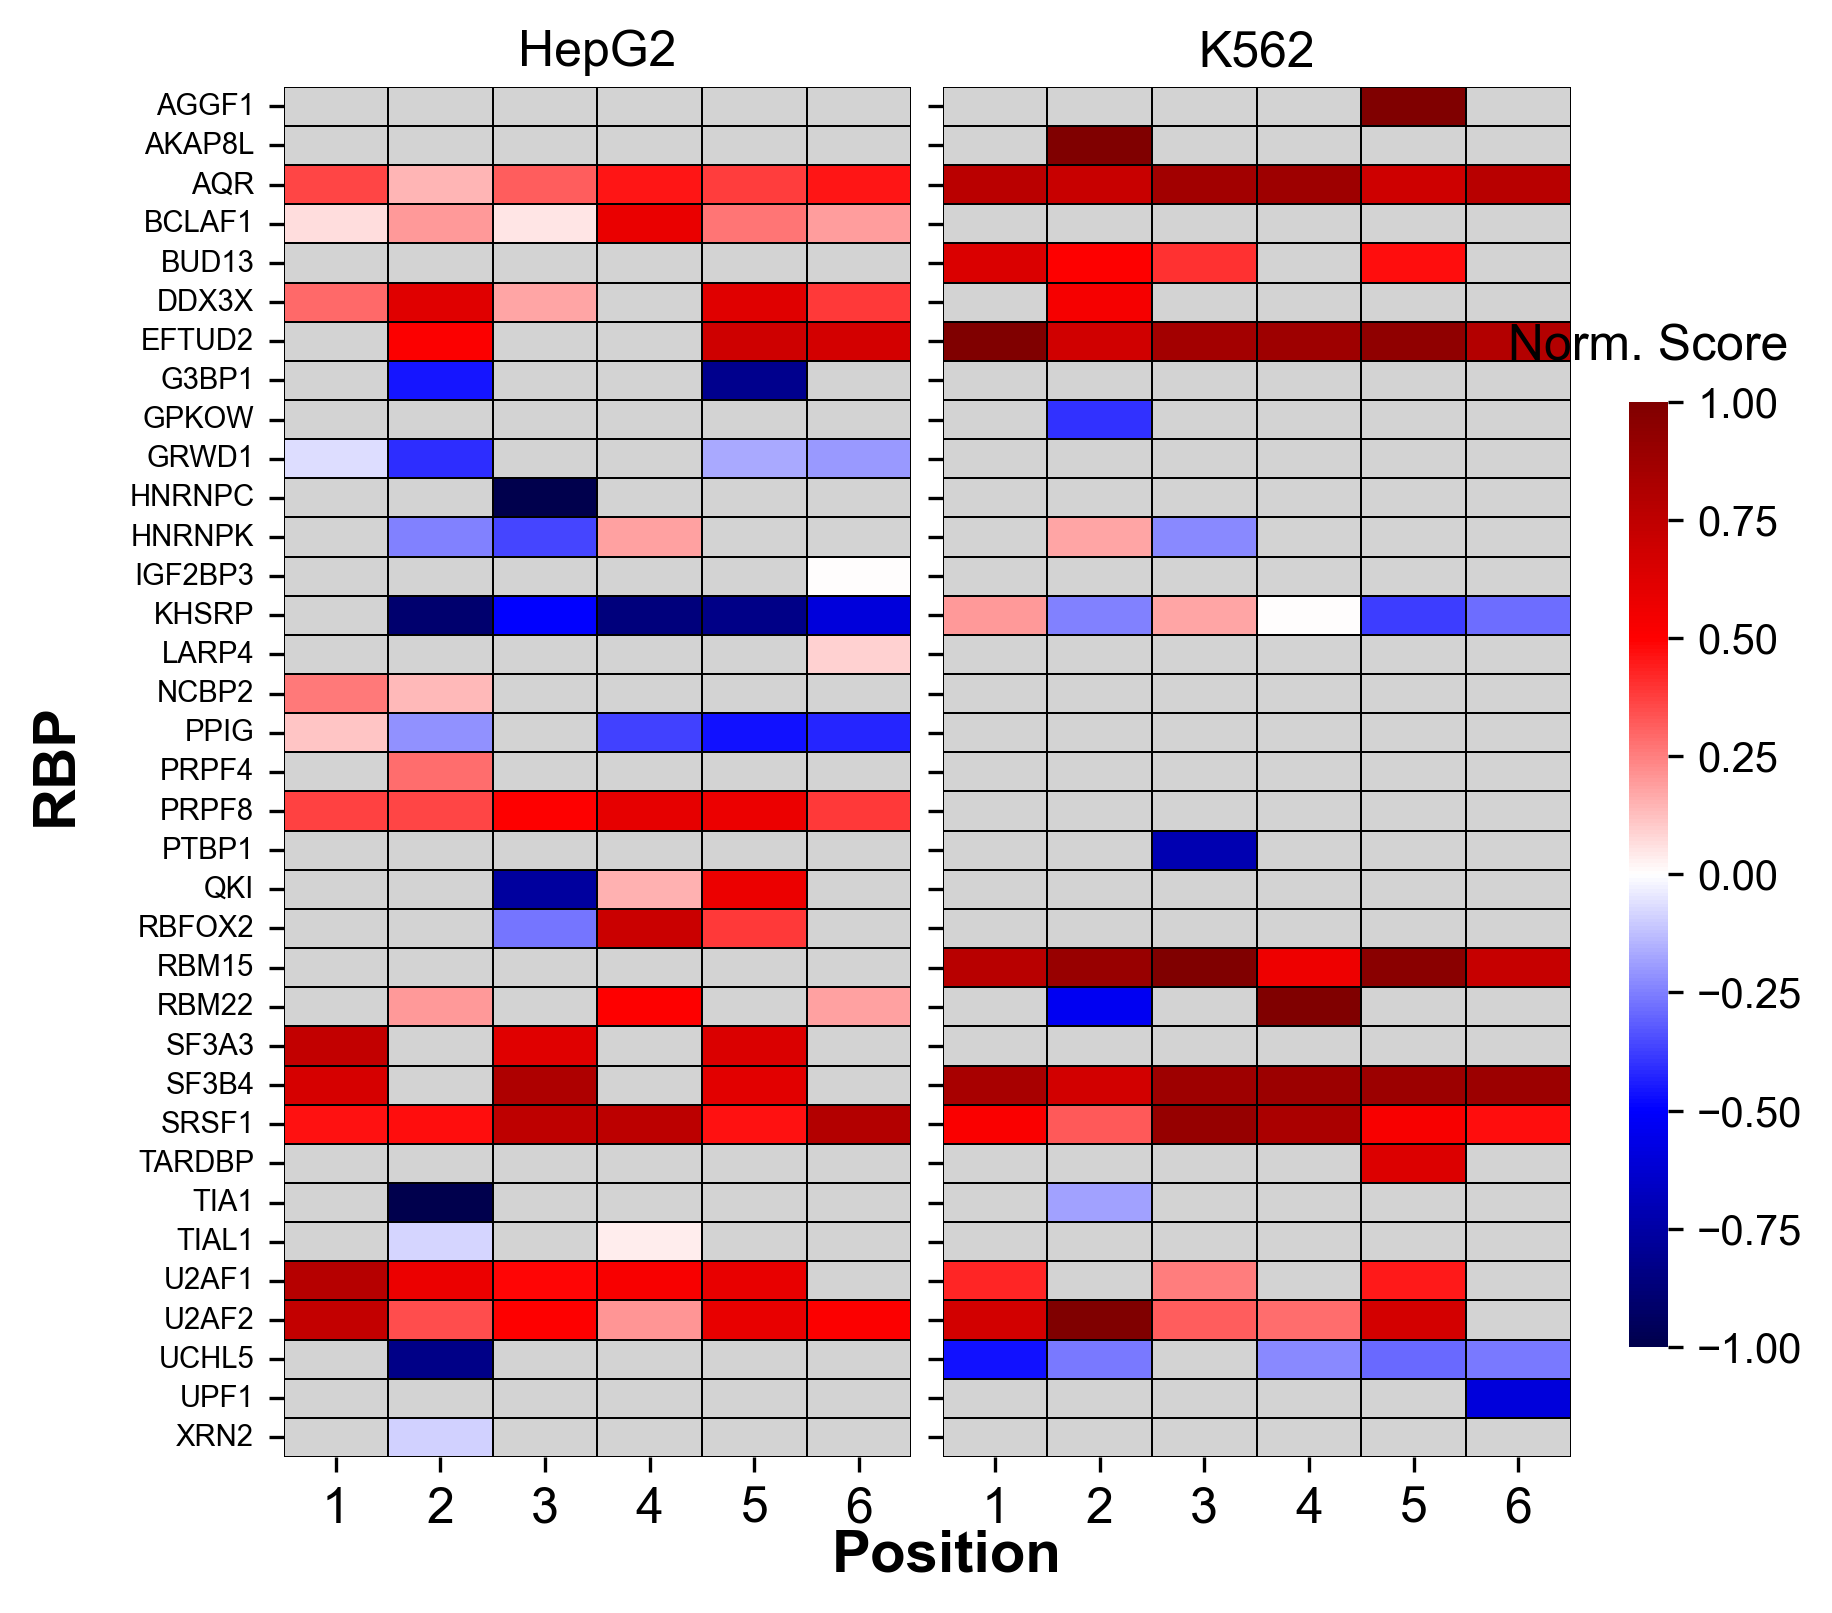

array([<Axes: title={'center': 'HepG2'}>,
       <Axes: title={'center': 'K562'}>], dtype=object)

In [17]:
plot_rbp_activity_heatmap_test(final_heatmap)

## SHAP vs RBP Activity Score Scatterplot

### This has the new SHAP data (log odds units)

In [14]:
glossary_data_path = f"/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/specialized_global_SHAP/signed_local_SHAP_mean_bound_only_unique_binding.pkl"

with open(glossary_data_path, 'rb') as f:
        data = pickle.load(f)

In [17]:
keys = list(data.keys())

HepG2_glossary = pd.DataFrame(data[keys[0]])
K562_glossary = pd.DataFrame(data[keys[1]])

# Write to cell_line_new_glossary_heatmap.csv

In [18]:
# Creating the source table

def rbp_activity_table(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 10 sig. points 

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "Position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    df = pd.DataFrame(results_df)

    glossary_data_path = f"/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/{cell_line}_new_glossary_heatmap.csv"

    glossary_data = pd.read_csv(glossary_data_path)
    
    # Melt glossary from wide to long so it matches activity data structure

    glossary_long = glossary_data.melt(id_vars="Position", var_name="RBP", value_name="shap")

    # Merge on position + RBP

    merged = df.merge(glossary_long, on=["RBP", "Position"], how="left")

    print(merged)

    pearson_corr = merged['norm_diff'].corr(merged['shap'], method='pearson')
    spearman_corr = merged['norm_diff'].corr(merged['shap'], method='spearman')

    print(f"Pearson correlation: {pearson_corr:.4f}")
    print(f"Spearman correlation: {spearman_corr:.4f}")
    
    # Scatterplot

    conditions = [
        (merged["shap"] > 0) & (merged["norm_diff"] > 0),   # Q1
        (merged["shap"] < 0) & (merged["norm_diff"] > 0),   # Q2
        (merged["shap"] < 0) & (merged["norm_diff"] < 0),   # Q3
        
        (merged["shap"] > 0) & (merged["norm_diff"] < 0),   # Q4
    ]

    colors = ["red", "gray", "blue", "gray"]

    merged["quadrant_color"] = np.select(conditions, colors, default="black")

    label = r'$\bar{\varphi}^b_i$'

    plt.style.use("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/paper.mplstyle")
    plt.figure(figsize=(8, 6))
    plt.scatter(merged["shap"], merged["norm_diff"], c=merged["quadrant_color"], alpha=0.5)

    # Add horizontal & vertical lines at 0 to create 4 quadrants
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    # Labels & title
    plt.xlabel(label, fontsize = 19, labelpad = 15)
    plt.ylabel("RBP Activity Score", fontsize = 19, labelpad = 15)
    plt.title(f"{cell_line}", fontsize = 19, pad = 15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.show()

    return

HepG2
      RBP  Position  num_pos  num_neg  norm_diff      shap
0     AQR         1       30       14   0.363636 -0.068490
1     AQR         2       31       23   0.148148 -0.177027
2     AQR         3       27       14   0.317073  0.912755
3     AQR         4       24        9   0.454545  0.586993
4     AQR         5       51       23   0.378378 -0.150674
..    ...       ...      ...      ...        ...       ...
83  U2AF2         4       41       27   0.205882 -0.305160
84  U2AF2         5      323       84   0.587224 -0.156785
85  U2AF2         6       25        8   0.515152 -0.048858
86  UCHL5         2        1       11  -0.833333 -0.415896
87   XRN2         2        5        6  -0.090909 -0.284059

[88 rows x 6 columns]
Pearson correlation: 0.1989
Spearman correlation: 0.1804


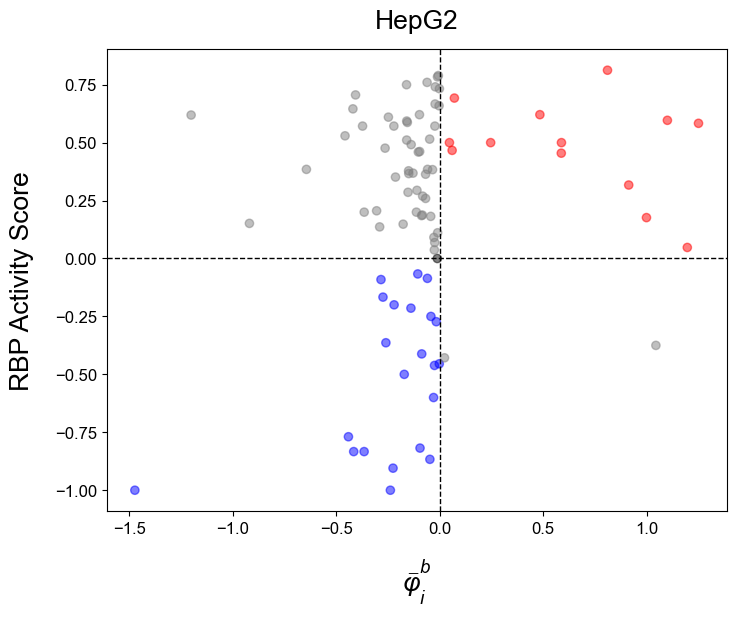

In [19]:
hepg2_data = rbp_activity_table('HepG2', data_HepG2)

K562
       RBP  Position  num_pos  num_neg  norm_diff      shap
0    AGGF1         5       13        0   1.000000 -0.009366
1   AKAP8L         2       12        0   1.000000 -0.000870
2      AQR         1      249       33   0.765957 -0.016039
3      AQR         2     1172      192   0.718475 -0.231833
4      AQR         3      340       25   0.863014  0.517747
..     ...       ...      ...      ...        ...       ...
60   UCHL5         2       10       17  -0.259259 -0.208452
61   UCHL5         4        5        8  -0.230769  0.923129
62   UCHL5         5        6       11  -0.294118 -0.173603
63   UCHL5         6        7       12  -0.263158 -0.081410
64    UPF1         6        2        8  -0.600000 -0.024331

[65 rows x 6 columns]
Pearson correlation: 0.2773
Spearman correlation: 0.4095


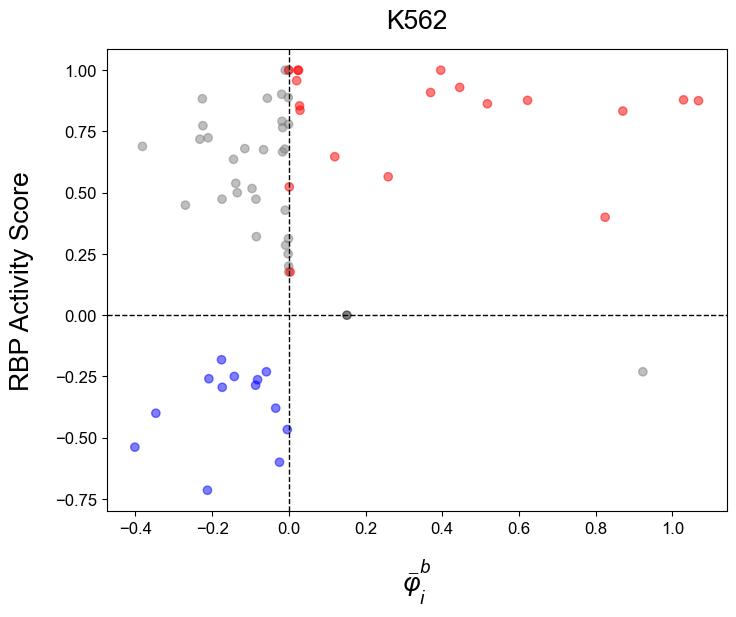

In [20]:
k562_data = rbp_activity_table('K562', data_K562)